In [4]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import numpy as np
import seaborn as sns

In [30]:
df = pd.read_csv("../complex_env_dual_arm_collision_2026-07-17_02-55-13.csv")
df.set_index("file", inplace=True)


algo_language = {
    "FCL distance": "C++",
    "Jolt intersection": "C++",
    "libccd intersection": "C++",
    "Bullet distance": "C++",
    "openGJK distance": "C++",

    "ncollide_distance": "Rust",
    "collision-rs_nasterov_gjk": "Rust",
    "collision-rs_distance_gjk": "Rust",
    "collision-rs_intersect_gjk": "Rust",
    "gjk-rs_nasterov_gjk": "Rust",

    "Pybullet": "Python",
    "distance3d Nesterov (with acceleration)": "Python",
    "distance3d Nesterov": "Python",
    "distance3d Jolt (intersection)": "Python",
    "distance3d Jolt (distance)": "Python",
    "distance3d Original": "Python",
}

In [ ]:
print("Plotting histograms:")

for algo in df.columns:

    n, bins, patches = plt.hist(df[algo], 50, density=True)
    # statistic, p = stats.normaltest(n)
    # print(f"Algorithm: {algo}; p-value: {p}")

    # sigma = np.std(df[algo])
    # x = np.linspace(mu - 3*sigma, mu + 3*sigma, 51)
    # normal_dist = stats.norm.pdf(x, mu, sigma)
    # plt.plot(x, normal_dist)
    print("Algo:", algo)
    plt.show()


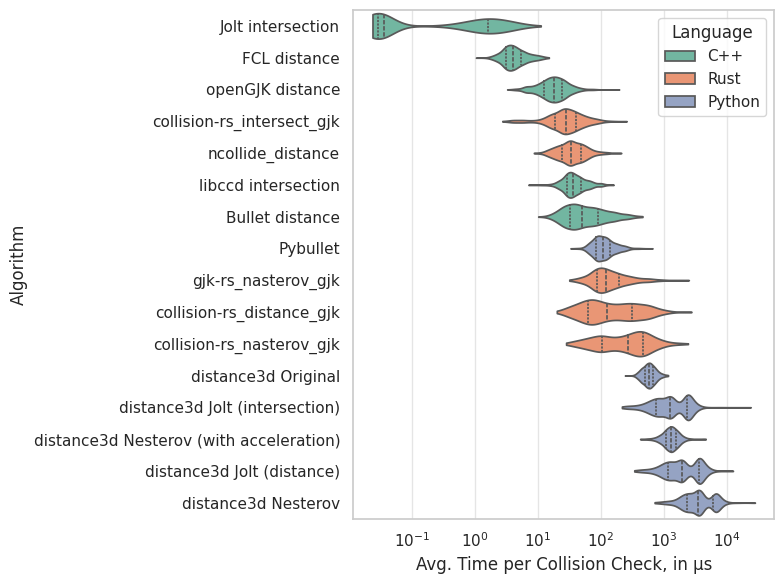

In [31]:
# Violin plot:

df_long = df.melt(var_name='Algorithm', value_name='Value')
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")
order = df_long.groupby('Algorithm')['Value'].median().sort_values(ascending=True).index.tolist()

df_long['Language'] = df_long['Algorithm'].map(algo_language)
languages = df_long['Language'].unique().tolist()
lang_colors = sns.color_palette('Set2', n_colors=len(languages))
lang_palette = dict(zip(languages, lang_colors))

sns.violinplot(
    data=df_long,
    y='Algorithm', x='Value',
    order=order, hue='Language', hue_order=languages,
    palette=lang_palette,
    # dodge=False,
    inner="quart", density_norm="count", log_scale=True, cut=0
)


plt.xlabel("Avg. Time per Collision Check, in µs")
plt.tight_layout()
plt.show()